# Reduced equations (steady state over parameter space)

In this notebook, I'll take our steady-state integration of the reduced equations (`reduced-eqs-steady-state.ipynb`) and apply it to a sample over the parameter space. More specifically, I'm interested in how the tilt ratio $\frac{W_\text{in}}{W_\text{out}}$ varies with the two parameters $\frac{h}\alpha$ and $k_0 = \frac{q}{\pi \epsilon h}$.

The system parameters I'll vary are:
- q: Ratio of the planet's mass to the star's mass.
- $\epsilon$: Gravitational softening term; prevents the gravitational force from diverging at the planet.
- h: Ratio of disk scale height to disk radius.
- $\alpha$: alpha viscosity parameter.

To keep things simpler, I won't vary $\epsilon$ as we can also change $k_0$ by changing $q$. (Our results actually depend on $\epsilon$ in a complicated way since, e.g., $R_+$ depends on $\epsilon$. Also, we don't actually know what value of $\epsilon$ we should use; we'll look into this in our simulations.)

In [189]:
eps = .11 # softening term
a = 1 # radial coordinate of planet
Rout = 3.5 # radial coordinate of disk's outer edge
use_gap = False # turns on/off gap in density profile

# Imports

In [190]:
import numpy as np
import pandas as pd
import tables
import time
import math
#import scipy.differentiate
import scipy.integrate as integ
import scipy.interpolate as interp

import matplotlib.pyplot as plt

# Disk information

Normalizations:
- $R_0 = 1$
- $\Omega_{K,0} = 1$ (so $GM = 1$)
- $\Sigma_0 = 1$

## Density profile

In [191]:
def Sigma(Rs, use_gap):
    '''
    Returns the disk's background surface density profile.
    If use_gap is False, do not include a gap in the profile.
    
    '''
    
    K, R_a, R_b, D_a, D_b = 19, 0.5, 1.5, 0.1, 0.2
    fgaps = f_gap(Rs, K, R_a, R_b, D_a, D_b, use_gap)
    
    Sigma0 = 1
    
    return Sigma0 * Rs**(-3/2) / fgaps

def f_gap(Rs, K, R_a, R_b, D_a, D_b, use_gap):
    '''
    Function that "shapes" the disk gap profile. Used in `sigma` function. 
    R_a and R_b are the locations of the inner and outer gap edges,
    D_a and D_b are the steepness of the edges, and K determines the
    depth of the gap.
    If use_gap is False, return 1 (i.e., no disk gap).
    
    '''

    if use_gap:
        return 1 + (K-1)/2 * \
            (np.tanh((Rs - R_a)/D_a) - np.tanh((Rs - R_b)/D_b))
    else:
        return 1

## Keplerian orbital frequency

Scale height, which depends on $\Omega$, is defined in the "Planet information" section below.

In [192]:
def OmegaK(Rs):
    '''
    Returns the Keplerian orbital frequency profile.
    Omega_K = sqrt(G*M_star / R^3)

    '''
    OmegaK_0 = 1 # Omega_K at R=R_0
    return OmegaK_0 * Rs**(-3/2)

# Planet information

## Laplace coefficients

In [193]:
def laplace_coeff_integrand(phi, x, j, s, eps):
    '''
    
    This function represents the integrand of the Laplace coefficient formula
    (Eq. 6.67 of Murray & Dermott). The result is used in the laplace_coeff function.
    
    PARAMETERS
    ----------
    phi: the variable that we integrate over (eg, an angle)
    x: the variable that isn't integrated over; argument of Laplace coeff function
    j, s: See Eq. 6.67 of Murray & Dermott or Eq. 21 in Lubow+Ogilvie.
    eps: gravitational softening term
    
    '''
    
    num = np.cos(j*phi) # numerator
    denom = (1 - 2 * x * np.cos(phi) + x**2 + eps**2) ** s
    
    return num / denom

def laplace_coeff(x, j, s, eps):
    '''
    
    Calculate the Laplace coefficient using Eq. 6.67 of Murray & Dermott.

    
    PARAMETERS
    ----------
    x: argument of the Laplace coefficient formula
    j, s: See Eq. 6.67 of Murray & Dermott or Eq. 21 in Lubow+Ogilvie.
    eps: gravitational softening term
    
    '''
    
    return 2 / np.pi * integ.quad(laplace_coeff_integrand, 0, np.pi, args=(x, j, s, eps))[0]

To speed things up, I'll interpolate the Laplace coefficients:

In [194]:
# interpolate Laplace coefficient function (~10x faster)
# large alpha limit
xs_temp = np.linspace(1+(1e-3 * eps), 110, 10000)
ys_temp = [laplace_coeff(x, j=0, s=3/2, eps=eps) for x in xs_temp]
b0_interp_large_alpha = interp.CubicSpline(xs_temp, ys_temp)

ys_temp = [laplace_coeff(x, j=1, s=3/2, eps=eps) for x in xs_temp]
b1_interp_large_alpha = interp.CubicSpline(xs_temp, ys_temp)

# small alpha limit
xs_temp = np.linspace(1e-3, 1-(1e-3 * eps), 1000)
ys_temp = [laplace_coeff(x, j=0, s=3/2, eps=eps) for x in xs_temp]
b0_interp_small_alpha = interp.CubicSpline(xs_temp, ys_temp)

ys_temp = [laplace_coeff(x, j=1, s=3/2, eps=eps) for x in xs_temp]
b1_interp_small_alpha = interp.CubicSpline(xs_temp, ys_temp)

And let's check that our approximated functions are accurate:

In [195]:
# correctness checks
print("Correctness check: for alpha >> 1, b^1_{3/2} ~ 3/alpha^4.")
x = 1 + 1e-2*eps
print(laplace_coeff(x, j=1, s=3/2, eps=eps))
#print(b1_approx(x,limit="large"))
print(b1_interp_large_alpha(x))

print("\nCorrectness check: for alpha >> 1, b^0_{3/2} ~ 2/alpha^3.")
x = 1+1e-2*eps
print(laplace_coeff(x, j=0, s=3/2, eps=eps))
#print(b0_approx(x,limit="large"))
print(b0_interp_large_alpha(x))

print("\nCorrectness check: for alpha << 1, b^1_{3/2} ~ 3*alpha.")
x = 1-1e-2*eps
print(laplace_coeff(x, j=1, s=3/2, eps=eps))
#print(b1_approx(x,limit="small"))
print(b1_interp_small_alpha(x))

print("\nCorrectness check: for alpha << 1, b^0_{3/2} ~ 2.")
x = 1-1e-2*eps
print(laplace_coeff(x, j=0, s=3/2, eps=eps))
#print(b0_approx(x,limit="small"))
print(b0_interp_small_alpha(x))


Correctness check: for alpha >> 1, b^1_{3/2} ~ 3/alpha^4.
51.757186605036416
51.758546306172455

Correctness check: for alpha >> 1, b^0_{3/2} ~ 2/alpha^3.
52.79969428498544
52.80105595564892

Correctness check: for alpha << 1, b^1_{3/2} ~ 3*alpha.
51.81260432820644
51.81260433232523

Correctness check: for alpha << 1, b^0_{3/2} ~ 2.
52.85820336744437
52.85820337156926


## Orbital, epicyclic, and radial frequencies

(I use Eqs. 25-27 in Lubow+Ogilvie 2000.)

In [196]:
def Omega(R, Mp, a):
    '''
    Returns the disk's orbital frequency at R. 
    
    VARIABLES:
    ----------
    R is the radial coordinate.
    Mp is the ratio of the planet's mass to the star mass (using the normalization 
    GM_star = 1). For example, if we assume M_star = 1 M_sun, then a Jupiter-mass
    planet would have Mp = 0.001.
    a is the radius of the planet's orbit.

    '''

    Omega_sq = OmegaK(R)**2
    alpha = R/a

    if alpha==1:
        raise ValueError("Can't have `a` in the list of Rs; otherwise, we have R/a = 1")

    planet_term = 0
    
    if alpha < 1:
        planet_term = Mp/(2 * a**2 * R) * (alpha*b0_interp_small_alpha(alpha) - \
                        b1_interp_small_alpha(alpha))
    elif alpha > 1:
        planet_term = Mp/(2 * a**2 * R) * (alpha*b0_interp_large_alpha(alpha) - \
                        b1_interp_large_alpha(alpha))
    Omega_sq += planet_term
    
    return np.sqrt(Omega_sq)

def Kappa(R, Mp, a):
    '''
    Returns the disk's epicyclic frequency at R. 
    
    VARIABLES:
    ----------
    R is the radial coordinate.
    Mp is the ratio of the planet's mass to the star mass (using the normalization 
    GM_star = 1). For example, if we assume M_star = 1 M_sun, then a Jupiter-mass
    planet would have Mp = 0.001.
    a is the radius of the planet's orbit.

    '''

    kappa_sq = OmegaK(R)**2
    alpha = R/a
    
    if alpha==1:
        raise ValueError("Can't have `a` in the list of Rs; otherwise, we have R/a = 1")

    planet_term = 0
    
    if alpha < 1:
        planet_term = Mp/(2 * a**2 * R) * (alpha*b0_interp_small_alpha(alpha) - \
                        2*b1_interp_small_alpha(alpha))
    elif alpha > 1:
        planet_term = Mp/(2 * a**2 * R) * (alpha*b0_interp_large_alpha(alpha) - \
                        2*b1_interp_large_alpha(alpha))
    kappa_sq += planet_term

    return np.sqrt(kappa_sq)

def Omega_z(R, Mp, a):
    '''
    Returns the disk's vertical frequency at R. 
    
    VARIABLES:
    ----------
    R is the radial domain.
    Mp is the ratio of the planet's mass to the star mass (using the normalization 
    GM_star = 1). For example, if we assume M_star = 1 M_sun, then a Jupiter-mass
    planet would have Mp = 0.001.
    a is the radius of the planet's orbit.

    '''

    Omegaz_sq = OmegaK(R)**2
    alpha = R/a
    
    if alpha==1:
        raise ValueError("Can't have `a` in the list of Rs; otherwise, we have R/a = 1")

    planet_term = 0
    
    if alpha < 1:
        planet_term = Mp/(2 * a**2 * R) * alpha*b0_interp_small_alpha(alpha)
    elif alpha > 1:
        planet_term = Mp/(2 * a**2 * R) * alpha*b0_interp_large_alpha(alpha)
    Omegaz_sq += planet_term

    return np.sqrt(Omegaz_sq)

# vectorize functions to avoid errors with the boolean comparisons
Omega = np.vectorize(Omega)
Kappa = np.vectorize(Kappa)
Omega_z = np.vectorize(Omega_z)

## Disk scale height

In [197]:
def scaleHeight(Rs, cs):
    '''
    Returns the disk's scale height profile. We use H = cs / Omega_K,
    where cs is the disk's sound speed (assumed to be constant throughout
    the disk).

    '''
    return cs / OmegaK(Rs)

## `compute_dGdR` and `compute_dWdR`

In [198]:
def compute_dGdR(R, W, Mp, a, use_gap):
    '''
    Returns dG/dR at a specific coordinate R. W is the value of tilt
    at R.
    
    Mp and a are the planet's mass and orbital radius respectively.

    `use_gap` toggles if the disk's background profile has a gap.
    
    '''

    S = Sigma(R, use_gap) 
    O = Omega(R, Mp, a)
    Oz = Omega_z(R, Mp, a)
    
    coeff1 = S * O**2 * R**3
    coeff2 = (Oz**2 - O**2) / (O**2) * (1j/2)
    
    return coeff1 * coeff2 * W

def compute_dWdR(R, G, Mp, cs, alpha, a, use_gap):
    '''
    Returns dW/dR at a specific coordinate R. G is the value of internal
    torque at R.
    
    cs is the disk's sound speed. Mp and a are the planet's mass and 
    orbital radius respectively. alpha is the viscosity parameter.

    `use_gap` toggles if the disk's background profile has a gap.
    
    '''

    S = Sigma(R, use_gap)
    H = scaleHeight(R, cs)
    O = Omega(R, Mp, a)
    K = Kappa(R, Mp, a)
    
    coeff1 = 4 / (S * H**2 * O**2 * R**3)
    coeff2 = (K**2 - O**2) / (O**2) * (1j/2) + alpha
    
    return coeff1 * coeff2 * G

# Compute $W_\text{in}/W_\text{out}$

In [199]:
def compute_Win_div_Wout(q, eps, h, alpha):
    '''
    Integrates the steady-state reduced equations to get
    the ratio of the disk's inner tilt to the outer tilt
    using the system parameters q, epsilon, h, and alpha (defined
    at the start of this notebook).

    '''

    cs = h # in our normalization, c_S = h

    # spatial domain
    Rmin = 0.5
    Rmax = Rout
    DeltaR = .03 # 0.03
    num_Rs = (int) ((Rmax - Rmin) / DeltaR) + 1
    
    # stagger W and G in the R domain
    Rs_warp = np.linspace(Rmin, Rmax, num_Rs)
    Rs_torque = np.zeros(shape=((num_Rs+1)))
    Rs_torque[0] = Rs_warp[0] - DeltaR/2
    Rs_torque[1:] = Rs_warp.copy() + DeltaR/2
    
    # initialize W and G arrays
    Ws = np.zeros(shape=((num_Rs)))
    Ws = Ws.astype(complex)
    Ws[0] = 1e-5 
    Gs = np.zeros(shape=Rs_torque.shape)
    Gs = Gs.astype(complex)
    Gs[0] = 0
    
    # integrate to get W and G by stepping FORWARD in R
    for i in np.arange(0, num_Rs):
        ## 1. Given G_{i-1/2} and W_i, update G_{i+1/2}
        W_i = Ws[i] # W_i
        dR = Rs_torque[i+1] - Rs_torque[i]
        R_i = Rs_warp[i]
    
        dGdR = compute_dGdR(R_i, W_i, q, a, use_gap)
        Gs[i+1] = Gs[i] + dGdR*dR
        
        ## 2. Given W_i and G_{i+1/2}, update W_{i+1}
        if (i == (num_Rs-1)): break # outer edge
        G_ihalf = Gs[i+1]
        dR = Rs_warp[i+1] - Rs_warp[i]
        R_ihalf = Rs_torque[i+1]
    
        dWdR = compute_dWdR(R_ihalf, G_ihalf, q, cs, alpha, a, use_gap)
        Ws[i+1] = Ws[i] + dWdR*dR
    
    # # apply our outer boundary condition
    # W_outer = 0.1
    # scaling = W_outer / Ws[-1]
    # Ws *= scaling
    # Gs *= scaling

    # calculate ratio of W_in to W_out
    Win_div_Wout = np.abs(Ws[0] / Ws[-1])

    return Win_div_Wout

compute_Win_div_Wout_vect = np.vectorize(compute_Win_div_Wout)

## Analytic form of $W_\text{in}/W_\text{out}$

In [245]:
# outer boundary for planet's region of influence
delta = a * (4*eps)
Rminus = a - delta
Rplus = a + delta

def ycoord(R, q, eps, h):
    '''
    Returns the dimensionless coordinate y(R), where 
    dy = Z(R)dR / ha.
    
    '''

    return q/(np.pi * eps * h) * \
        np.arctan(((R/a) - 1)/eps)

In [240]:
def Win_div_Wout_analytic(q, eps, h, alpha):
    '''
    Using our analytic approximation of W(R), computes
    the ratio of the disk's inner tilt to the outer tilt
    using the system parameters q, epsilon, h, and alpha (defined
    at the start of this notebook).

    '''

    k = ycoord(Rplus, q, eps, h)
    denom = np.cosh(2*k)**2 + \
        16*(alpha/h)**2 * (np.sqrt(Rout) - np.sqrt(a))**2 / a * np.sinh(2*k)**2
    return 1 / np.sqrt(denom)

def halpha_vs_k0_analytic(k0):
    '''
    Given k_0, compute the value of h/alpha such that 
    W_in/W_out = 0.5.

    '''

    k = k0 * np.arctan(((Rplus/a) - 1)/eps)
    num = 16*np.sinh(2*k)**2
    denom = 4 - np.cosh(2*k)**2

    return np.sqrt(num / denom)

In [241]:
def compute_k0(q, eps, h, alpha):
    '''
    Computes the parameter k_0.
    
    '''

    return q / (np.pi * eps * h)

## Visualize over parameter space

In [203]:
N = 10
h_ctrl = 0.02 # h in "control" set of parameters

alphas = h_ctrl / np.linspace(1, 10, N)
qs = 3e-3 * np.ones(shape=(alphas.shape))

# qs, alphas = np.meshgrid(qs, alphas)
epses = eps*np.ones(shape=(qs.shape))
hs = h_ctrl*np.ones(shape=(qs.shape))

In [204]:
start = time.time()
Wratios = compute_Win_div_Wout_vect(qs, epses, hs, alphas)
print("Time elapsed (s):", np.round(time.time()-start,1))

Time elapsed (s): 0.1


In [205]:
h_div_alphas = (hs/alphas).flatten()
k0s = compute_k0(qs, epses, hs, alphas)
k0s = k0s.flatten()

In [206]:
def plot_Wratios(h_div_alphas, k0s, Wratios):
    '''
    Plot W_in/W_out over the (h/alpha, k_0) parameter space.
    
    '''
    
    # plot the "border" between breaking and non-breaking regimes
    xs_border = np.asarray([1,2,3,4,5, 8.5])
    ys_border = [0.286, 0.398, 0.424, 0.458, 0.462, 0.477]
    
    #plt.plot(xs_border, ys_border, color="black", ls="--", label="True")
    # plt.plot(xs_border, .1*np.log(1.3*xs_border) + 0.286, color="black")
    
    k0s_border = np.linspace(0.1, 0.49, N)
    plt.plot(halpha_vs_k0_analytic(k0s_border), k0s_border, color="black", \
             label=r"Analytic ($R_+=a(1+4\epsilon)$)")
    
    plt.scatter(h_div_alphas, k0s, c=Wratios, vmin=0, vmax=1, cmap='coolwarm')
    plt.xlabel(r"$h/\alpha$")
    plt.ylabel(r"$k_0 \sim q/(\epsilon h)$")
    
    plt.xlim(0, 10)
    plt.ylim(0, 1)
    
    plt.colorbar(label=r"$\mathcal{W}_\text{in}/\mathcal{W}_\text{out}$")
    
    #plt.scatter([],[], s=0, label="Rplus=" + str(Rplus))
    
    plt.legend(loc='upper right')
    
    save_fig = False
    if save_fig:
        plt.savefig("Figures/k0_vs_halpha.png")
    plt.show()

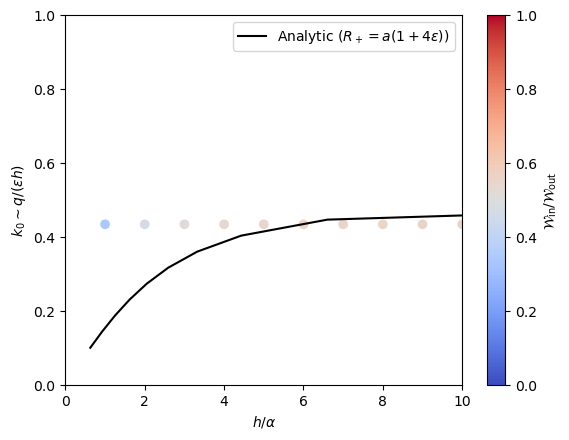

In [207]:
plot_Wratios(h_div_alphas, k0s, Wratios)

## changing only $\epsilon$

In [246]:
# combine new eps data with existing eps data
h_div_alphas_all = np.concatenate((h_div_alphas_eps, h_div_alphas))
k0s_all = np.concatenate((k0s_eps, k0s))
Wratios_all = np.concatenate((Wratios_eps, Wratios))

data_all = np.stack((h_div_alphas_all, k0s_all, Wratios_all))

In [209]:
file_path = "Data/Wratios/eps=0.05-0.15,hdivalpha=1-10.npy"

save_data = True
if save_data:
    with open(file_path, 'wb') as f:
        np.save(f, data_all)

load_data = True
if load_data:
    with open(file_path, 'rb') as f:
        data_all_loaded = np.load(f)

h_div_alphas_eps, k0s_eps, Wratios_eps = \
    data_all_loaded[0], data_all_loaded[1], data_all_loaded[2]

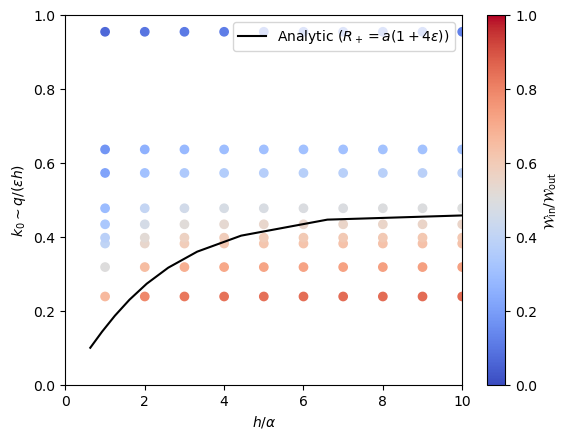

In [210]:
h_div_alphas_epses, k0s_epses, Wratios_epses = \
    data_all_loaded[0], data_all_loaded[1], data_all_loaded[2]

plot_Wratios(h_div_alphas_epses, k0s_epses, Wratios_epses)

## "original" dataset (changing $q$ and $\alpha$)

In [18]:
file_path = "Data/Wratios/q=5e-4to5e-3,hdivalpha=1-10.npy"

save_data = False
if save_data:
    with open(file_path, 'wb') as f:
        np.save(f, data_orig)

load_data = True
if load_data:
    with open(file_path, 'rb') as f:
        data_orig_loaded = np.load(f)

h_div_alphas_orig, k0s_orig, Wratios_orig = data_orig_loaded[0],\
    data_orig_loaded[1], data_orig_loaded[2]

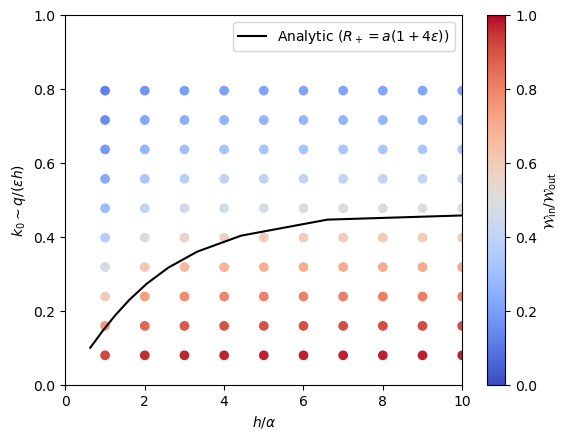

In [211]:
plot_Wratios(h_div_alphas_orig, k0s_orig, Wratios_orig.flatten())

## changing only $h$

In [234]:
# compute (h/alpha, k0, Wratio) for an arbitrary point

N = 30
q_arbs = 2.5e-3 * np.ones((N))
eps_arbs = .1 * np.ones((N))
alpha_arbs = .01 * np.ones((N))
h_arbs = np.linspace(.013, .04, N)

Wratio_arbs = compute_Win_div_Wout_vect(q_arbs, eps_arbs, h_arbs, alpha_arbs)
k0_arbs = compute_k0(q_arbs, eps_arbs, h_arbs, alpha_arbs)

/var/folders/5n/0c1hg8pn7lz4zsrbybrzwr5r0000gn/T/ipykernel_61273/1771930621.py:26: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(num / denom)


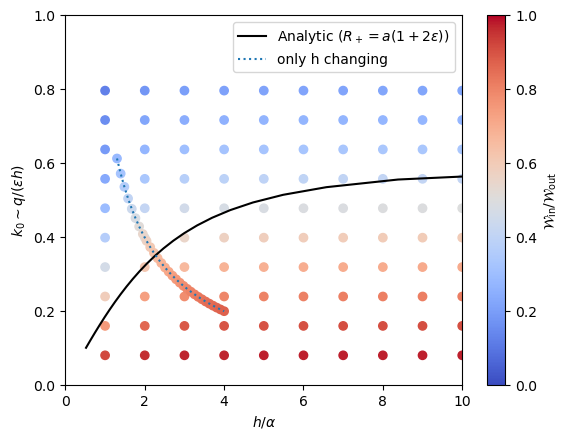

In [244]:
# plot the "border" between breaking and non-breaking regimes
xs_border = np.asarray([1,2,3,4,5, 8.5])
ys_border = [0.286, 0.398, 0.424, 0.458, 0.462, 0.477]

#plt.plot(xs_border, ys_border, color="black", ls="--", label="True")
# plt.plot(xs_border, .1*np.log(1.3*xs_border) + 0.286, color="black")

k0s_border = np.linspace(0.1, 0.7, N)
plt.plot(halpha_vs_k0_analytic(k0s_border), k0s_border, color="black", \
         label=r"Analytic ($R_+=a(1+2\epsilon)$)")

plt.scatter(h_div_alphas_orig, k0s_orig, c=Wratios_orig,\
            vmin=0, vmax=1, cmap='coolwarm')
plt.xlabel(r"$h/\alpha$")
plt.ylabel(r"$k_0 \sim q/(\epsilon h)$")

plt.scatter(h_arbs/alpha_arbs, k0_arbs,c=Wratio_arbs, vmin=0, vmax=1, \
            cmap='coolwarm')
plt.plot(h_arbs/alpha_arbs, k0_arbs, ls=':', label="only h changing")
            
plt.xlim(0, 10)
plt.ylim(0, 1)

plt.colorbar(label=r"$\mathcal{W}_\text{in}/\mathcal{W}_\text{out}$")

#plt.scatter([],[], s=0, label="Rplus=" + str(Rplus))

plt.legend(loc='upper right')

save_fig = False
if save_fig:
    plt.savefig("Figures/k0_vs_halpha-diff_Rplus.png")
plt.show()